# World Cup 2026: an honest expected-goals chart, and the profile that survives every filter

A debate I kept circling back to while rebuilding this chart was really a question of what a graph claims to show versus what it measures underneath, which I found compelling in the same way that comparing presidential approval polls from the past and now could be (LBJ compared to Biden, for example), where surface reading comes apart once you look closer. An approval rating looks like one clean measure of how a president is doing, yet LBJ's steady slide and Biden's flat line are produced by completely different machinery underneath, one by real events moving persuadable voters, the other by a polarization that pins the number in place almost regardless of what happens. Read the two side by side and the metric you thought you understood turns out to be measuring two different things. A football chart can do the same thing, quietly, and the one I started with does exactly that.

The chart came from footballytics, plotting World Cup 2026 attackers along a blended vertical axis of 0.3 times goals plus 0.7 times xG per 90. The concept is reasonable: two axes to separate scorers from creators, per-90 rates to compare players across uneven minutes. But three problems in the execution were serious enough that I rebuilt the whole thing.

**The vertical axis measured the wrong thing.** It was labeled finishing quality, but the formula underneath, a weighted blend of goals and xG, tracks shot volume and chance quality, not finishing. A high-volume shooter posts a large number on that axis whether or not he actually converts, because most of the number is his xG, and xG measures the chances he got into, not what he did with them. Genuine finishing is the gap between the two: goals minus xG, the overperformance a player generates beyond what his chances predicted. A striker who scores five from three xG worth of chances finished brilliantly; one who scored three from five xG finished poorly; and the blended axis hands them nearly identical scores because it never subtracts one from the other. So I moved the vertical axis to goals per 90 minus xG per 90, which is finishing and nothing else.

**Creation needed the right metric.** Once the finishing axis was fixed I still needed the second dimension the original was reaching for. I used xA per 90, expected assists, because xA credits the quality of the chance a player builds for a teammate, valuing a cutback into an open six-yard box far above a hopeful cross, and it does not punish a creator whose teammates fail to finish. Raw assists would: a perfect through ball the striker skies is still a perfect piece of creation, and xA captures that while the assist column does not. So xA isolates the creation a player controls from the conversion he does not.

**Small samples were treated as equal.** A World Cup gives each player only a handful of games, and the original weighted a cameo substitute the same as a player who started every match. A striker who scored twice in ninety minutes shows a per-90 finishing rate that dwarfs a player who overperformed steadily across six matches, and the reader has no way to tell which is real. I applied a 350-minute floor to drop the true cameos, and I sized every dot by minutes played, so that whatever sample noise survives the floor is at least visible: a small dot is a warning.

### Who is in the set, and why the rule is symmetric

A player is in the set if he generated **1.3 or more expected goals (xG) OR 1.3 or more expected assists (xA)** across the tournament, and played at least 350 minutes. Both gates use the same unit, expected goals, one pointed at scoring and one at creating, so the two sides are directly comparable rather than one being a shot count and the other an expected value. This deliberately keeps two kinds of player a one-sided rule would wrongly drop: pure finishers who shoot often but rarely create, and pure creators, often midfielders, who create constantly but rarely shoot. A finishing-only chart erases the second group; a creation-only chart erases the first.

One deliberate choice underpins the rule: the gates use xG and xA, not goals and assists. That mirrors the analysis itself, which trusts expected values over outcomes because outcomes over five games are noisy while expected values, built from many underlying events, are the stabler signal. A player with four assists on 0.9 xA is mostly the creation-side mirror of a lucky finisher: his teammates converted better than the chances warranted, so his assist count overstates his creation. That said, the gap is not pure luck; a persistent assists-over-xA gap can also reflect creation a model underrates. Over a five-game sample the noise reading dominates, so gating on xA rather than assists is the honest call, while acknowledging it is not the whole story.

Finishing figures (goals, xG, shots, efficiency) come from FIFA's official tournament stats; creation (xA) from FotMob. Each axis is single-source, so no metric mixes providers.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("wc2026_attackers.csv")
df["xa_p90"]  = df["xa_total"]/df["minutes"]*90
df["fin_p90"] = (df["goals"]-df["xg_total"])/df["minutes"]*90   # finishing = goals minus xG
df.sort_values("xa_p90", ascending=False).head()

,name,goals,xg_total,shots,xa_total,minutes,xa_p90,fin_p90
1,Messi,8,6.18,35,4.2,762,0.496063,0.214961
11,Olise,0,2.34,20,3.3,666,0.445946,-0.316216
15,Wirtz,0,0.97,10,1.7,363,0.421488,-0.240496
16,Madueke,0,0.61,6,1.6,364,0.395604,-0.150824
13,Trossard,2,1.67,17,2.2,515,0.384466,0.057670


## Chart 1: finishing versus creation, per 90, sized by minutes

Vertical axis is finishing (goals minus xG per 90). Horizontal is creation (xA per 90). Dot size is minutes played, so a small dot flags a thinner sample even among players past the floor. There are no quadrant labels and no verdicts: where a player sits is the information. The next sections calibrate how firmly each of the two readings can actually be pushed, because the two axes are not equally trustworthy over a sample this short.

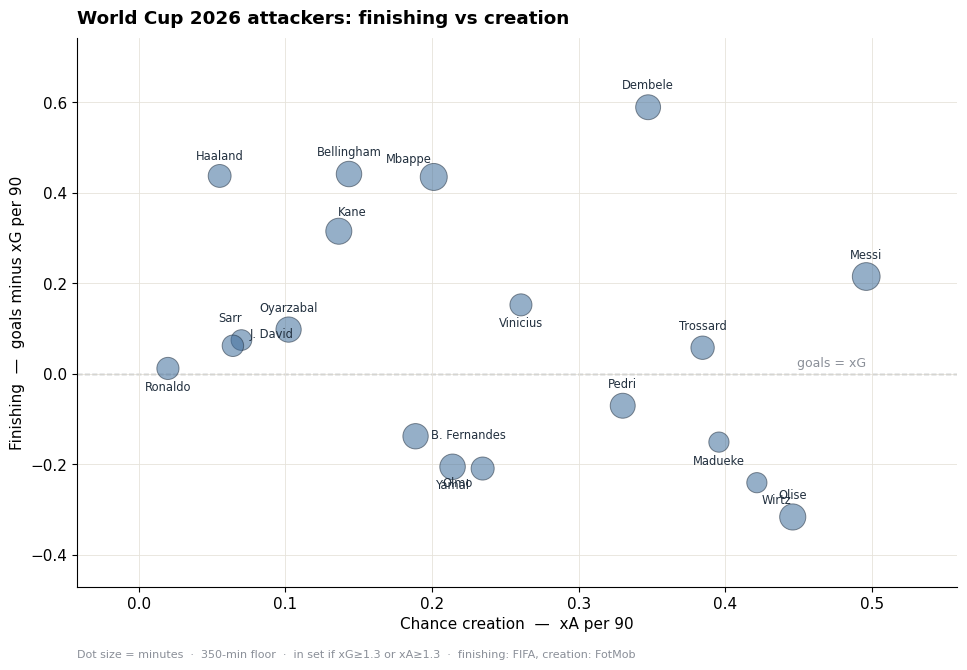

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
INK,ACC,MUT,GRID="#22303f","#3f6d9c","#8a8f98","#e6e3db"
plt.rcParams.update({"font.size":11,"figure.facecolor":"white","axes.facecolor":"white"})
df=pd.read_csv("wc2026_attackers.csv")
df["xa_p90"]=df["xa_total"]/df["minutes"]*90
df["fin_p90"]=(df["goals"]-df["xg_total"])/df["minutes"]*90
# CHART 1
fig,ax=plt.subplots(figsize=(9.8,6.8))
sz=(df["minutes"]/df["minutes"].max()*360)+40
ax.scatter(df["xa_p90"],df["fin_p90"],s=sz,color=ACC,alpha=.55,edgecolor=INK,lw=.7,zorder=3)
ax.axhline(0,color=MUT,lw=1,ls="--",zorder=1)
ax.text(df["xa_p90"].max(),.01,"goals = xG",color=MUT,fontsize=9,ha="right",va="bottom")
off={"Bellingham":(0,13),"Dembele":(0,13),"Kane":(10,11),"Mbappe":(-18,10),"Haaland":(0,12),
 "Vinicius":(0,-16),"Trossard":(0,13),"Olmo":(-18,-13),"B. Fernandes":(38,-2),"Wirtz":(14,-15),
 "Madueke":(0,-16),"Pedri":(0,13),"Olise":(0,13),"Messi":(0,13),"Yamal":(0,-16),
 "Ronaldo":(0,-16),"J. David":(28,6),"Sarr":(-8,13),"Oyarzabal":(0,13)}
for _,r in df.iterrows():
    dx,dy=off.get(r["name"],(0,12))
    ax.annotate(r["name"],(r["xa_p90"],r["fin_p90"]),xytext=(dx,dy),textcoords="offset points",ha="center",fontsize=8.3,color=INK)
ax.set_xlabel("Chance creation  \u2014  xA per 90"); ax.set_ylabel("Finishing  \u2014  goals minus xG per 90")
ax.set_title("World Cup 2026 attackers: finishing vs creation",fontweight="bold",loc="left",pad=10)
ax.grid(color=GRID,lw=.6,zorder=0); ax.margins(x=.13,y=.17)
ax.text(0,-.13,"Dot size = minutes  \u00b7  350-min floor  \u00b7  in set if xG\u22651.3 or xA\u22651.3  \u00b7  finishing: FIFA, creation: FotMob",transform=ax.transAxes,fontsize=8,color=MUT)
for s in["top","right"]:ax.spines[s].set_visible(False)
plt.tight_layout();plt.show()


How to read it. Far right is an elite creator: Messi sits alone out there, off the largest minutes total in the set, so his position is not a small-sample rate. High up are the players who beat their expected goals, Dembele, Bellingham, Mbappe, Haaland, Kane. Notice that Messi is not among them; on finishing he sits mid-pack, a good overperformer but well behind the best. The low-centre cluster, Pedri, Wirtz, Madueke, Olmo, Bruno Fernandes, are creators who barely shoot, so their finishing sits near or below zero, which is exactly right for their role and exactly why the symmetric rule keeps them: drop them and the chart pretends creation without shooting does not exist.

Before trusting any vertical position, though, it is worth asking how noisy that finishing axis really is, because the honest answer changes how you read the whole top half.

## Calibrating the finishing axis: how firmly can you read it?

Finishing rests on rare events. A player takes only a few shots a game, and each shot converts with a small probability equal to its xG, so his goals-minus-xG figure over a tournament sits on a handful of Bernoulli trials. One shot that flies in or clips the post swings the number hard. To put a number on that uncertainty, I model each player's goal count as a sum of Bernoulli trials, one per real shot, each with success probability equal to his average per-shot xG. The standard deviation of goals minus xG is then the binomial spread over his real shot count, which I convert to a per-90 band to match the axis.

The point this makes is not that the finishing axis is worthless. It is that a short-tournament finishing number should be read as what happened, not as proven skill you can project forward.

In [3]:
p = (df["xg_total"]/df["shots"]).clip(upper=0.99)       # average per-shot xG, from real shots
df["sd_goals"] = np.sqrt(df["shots"]*p*(1-p))          # SD of the goal count (binomial)
df["fin_ci95"] = 1.96*df["sd_goals"]/df["minutes"]*90  # 95% band in per-90 units
crosses = ((df["fin_p90"]-df["fin_ci95"]<0)&(df["fin_p90"]+df["fin_ci95"]>0)).sum()
print(f"{crosses} of {len(df)} finishing bands cross zero.")
df.sort_values("fin_p90",ascending=False)[["name","minutes","shots","fin_p90","fin_ci95"]].round(3)

18 of 19 finishing bands cross zero.


,name,minutes,shots,fin_p90,fin_ci95
12,Dembele,596,20,0.589,0.406
4,Bellingham,628,19,0.441,0.495
2,Haaland,490,19,0.437,0.673
0,Mbappe,716,41,0.435,0.578
5,Kane,660,23,0.315,0.470
1,Messi,762,35,0.215,0.522
7,Vinicius,449,17,0.152,0.636
3,Oyarzabal,617,23,0.098,0.536
6,Sarr,386,17,0.075,0.776
9,J. David,421,18,0.062,0.636


Eighteen of nineteen finishing bands cross zero. In plain terms: once you account for how few shots each number rests on, almost no player's finishing is statistically distinguishable from average over this sample. That does not delete the finishing axis, it disciplines it. Dembele really did out-finish the field in these games, but the honest reading is that his overperformance is what happened across five matches, not a proven rate you would bet on repeating. The creation axis, by contrast, rests on far more events per player, so it needs no such heavy discount, which the next section verifies directly rather than assuming.

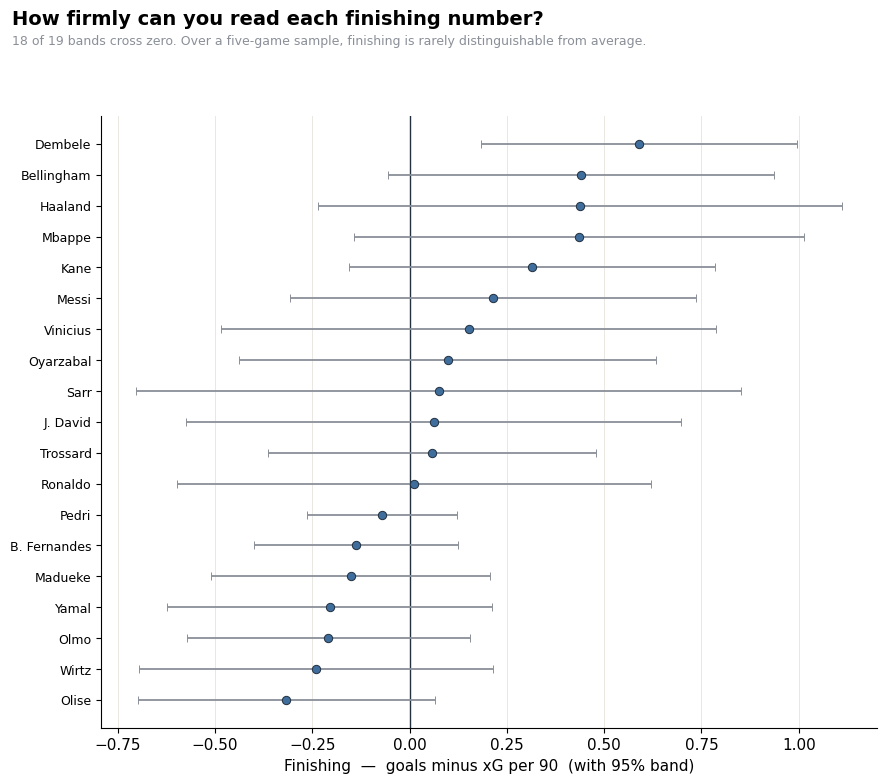

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
INK,ACC,MUT,GRID="#22303f","#3f6d9c","#8a8f98","#e6e3db"
plt.rcParams.update({"font.size":11,"figure.facecolor":"white","axes.facecolor":"white"})
df=pd.read_csv("wc2026_attackers.csv")
df["xa_p90"]=df["xa_total"]/df["minutes"]*90
df["fin_p90"]=(df["goals"]-df["xg_total"])/df["minutes"]*90
p=(df["xg_total"]/df["shots"]).clip(upper=0.99)
df["sd_goals"]=np.sqrt(df["shots"]*p*(1-p))
df["fin_ci95"]=1.96*df["sd_goals"]/df["minutes"]*90
# CHART 2
d2=df.sort_values("fin_p90"); y=np.arange(len(d2))
fig,ax=plt.subplots(figsize=(9,7.8))
ax.errorbar(d2["fin_p90"],y,xerr=d2["fin_ci95"],fmt="o",color=ACC,ecolor=MUT,elinewidth=1.3,capsize=3,markersize=6,markeredgecolor=INK,markeredgewidth=.7,zorder=3)
ax.axvline(0,color=INK,lw=1,zorder=2); ax.set_yticks(y);ax.set_yticklabels(d2["name"],fontsize=9)
ax.set_xlabel("Finishing  \u2014  goals minus xG per 90  (with 95% band)")
ax.grid(axis="x",color=GRID,lw=.6,zorder=0)
for s in["top","right"]:ax.spines[s].set_visible(False)
cr=int(((d2["fin_p90"]-d2["fin_ci95"]<0)&(d2["fin_p90"]+d2["fin_ci95"]>0)).sum())
fig.suptitle("How firmly can you read each finishing number?",fontweight="bold",fontsize=14,x=.02,ha="left",y=1.0)
fig.text(.02,.955,f"{cr} of {len(d2)} bands cross zero. Over a five-game sample, finishing is rarely distinguishable from average.",fontsize=9,color=MUT,ha="left")
plt.tight_layout(rect=[0,0,1,.93]);plt.show()


## Calibrating the creation axis: is xA measuring something real?

Creation is a higher-volume signal than finishing. A player creates chances many times per match, where he scores rarely, so xA accumulates over far more underlying events in the same minutes and the random swings cancel out faster. That is the theoretical reason to trust the creation axis more than the finishing axis. But xA is still a model estimate, so it is worth checking against reality: does a high xA reflect genuine creation, or a player whose teammates happened to finish his chances? Plotting xA against actual assists answers it. On the diagonal, a player's chances converted exactly as their quality predicted.

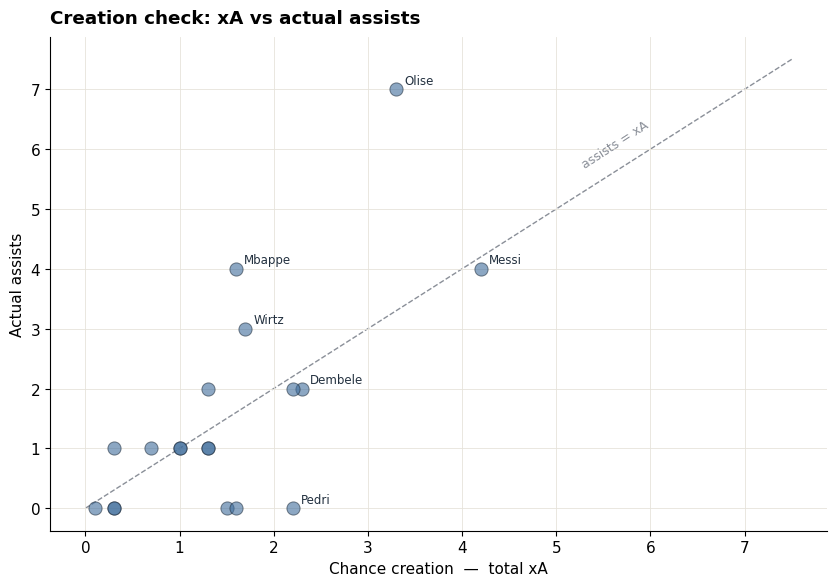

In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
INK,ACC,MUT,GRID="#22303f","#3f6d9c","#8a8f98","#e6e3db"
plt.rcParams.update({"font.size":11,"figure.facecolor":"white","axes.facecolor":"white"})
df=pd.read_csv("wc2026_attackers.csv")
df["xa_p90"]=df["xa_total"]/df["minutes"]*90
df["fin_p90"]=(df["goals"]-df["xg_total"])/df["minutes"]*90
p=(df["xg_total"]/df["shots"]).clip(upper=0.99)
df["sd_goals"]=np.sqrt(df["shots"]*p*(1-p))
df["fin_ci95"]=1.96*df["sd_goals"]/df["minutes"]*90
# CHART 3
assists={"Messi":4,"Olise":7,"Dembele":2,"Trossard":2,"Pedri":0,"Wirtz":3,"Madueke":0,"Olmo":2,"B. Fernandes":1,"Mbappe":4,"Yamal":0,"Vinicius":1,"Bellingham":1,"Kane":1,"Oyarzabal":1,"Haaland":0,"Sarr":1,"Ronaldo":0,"J. David":0}
df["assists"]=df["name"].map(assists)
fig,ax=plt.subplots(figsize=(8.5,6))
ax.scatter(df["xa_total"],df["assists"],s=90,color=ACC,alpha=.6,edgecolor=INK,lw=.7,zorder=3)
lim=max(df["xa_total"].max(),df["assists"].max())+.5
ax.plot([0,lim],[0,lim],color=MUT,ls="--",lw=1,zorder=1)
ax.text(lim*.7,lim*.76,"assists = xA",color=MUT,fontsize=9,rotation=33)
for nm in ["Messi","Olise","Dembele","Pedri","Wirtz","Mbappe"]:
    if nm in df.name.values:
        r=df[df.name==nm].iloc[0]; ax.annotate(nm,(r["xa_total"],r["assists"]),xytext=(6,4),textcoords="offset points",fontsize=8.5,color=INK)
ax.set_xlabel("Chance creation  \u2014  total xA"); ax.set_ylabel("Actual assists")
ax.set_title("Creation check: xA vs actual assists",fontweight="bold",loc="left",pad=10)
ax.grid(color=GRID,lw=.6,zorder=0)
for s in["top","right"]:ax.spines[s].set_visible(False)
plt.tight_layout();plt.show()


Messi sits almost exactly on the line: 4.2 xA, 4 actual assists. His creation converted at close to the expected rate, so his league-leading xA is not a mirage propped up by teammate finishing, it is real chance-creation that simply got finished as often as it should have. Olise sits well above the line, 3.3 xA and 7 assists, meaning his teammates finished his chances better than their quality warranted, so his raw assist total flatters his creation. Pedri sits below, 2.2 xA and 0 assists, his chances wasted. This is the entire case for building the axis on xA rather than assists, shown in one chart: assists are the noisy outcome, xA is the stabler input, and only for Messi do the two agree at the top.

## What I take from this, and the one profile that survives every filter

The rebuilt chart fixes the original's flaws: a finishing axis that measures finishing, a creation axis that isolates creation, a minutes floor and minute-sized dots that stop cameo samples from distorting the picture, and a symmetric rule that keeps scorers and creators alike. The statistics do not throw the finishing axis away, they calibrate it, telling you to read a short-tournament finishing number as what happened rather than proven skill, while the creation axis, resting on far more events and validated against actual assists, carries more weight on its own.

One conclusion survives every filter I applied. The whole point was to show how little a five-game sample supports, and the confidence bands make that case bluntly: eighteen of nineteen finishing numbers cannot be separated from average once you account for how few shots they rest on. Messi is the exception, and the reason is worth sitting with. His standout number is not finishing, where the uncertainty is widest and his overperformance ranks only sixth, behind Dembele, Bellingham, Haaland, Mbappe, and Kane. It is creation. Because chance creation accumulates over far more events than goals do, xA steadies at a sample size where finishing is still guesswork, and Messi's creation does not sit slightly ahead of the field, it laps it: his xA per 90 leads every player here, his total of 4.2 clears the next best by nearly a full expected assist, and, crucially, it holds on both totals and per 90 at once. That last point matters, because it means his lead is neither an artifact of playing the most minutes (per 90 controls for that) nor of a hot rate in a thin sample (the floor and the totals control for that). It survives every adjustment I could apply. He posts it while still finishing above his own expected goals, at 39.

Read as strictly as the sample allows, that is the profile that survives every filter this analysis applies: not the tournament's best finisher, but a genuinely above-average one who is also, by a wide and well-calibrated margin, its best creator, and the only player whose standout number holds up on the axis the statistics say you can actually trust.

## A closing opinion, beyond the data

What the numbers cannot say, I will. Watching Messi lead this tournament in creation while still scoring above his chances, at 39, tells me something the confidence bands are built to stay quiet about. The analysis holds him to the same five-game standard as everyone else and he is the one player left standing, but my read goes further than that. The rare thing is not that he finishes well or creates well in isolation, plenty of players do one. It is that he does both at once, at an age where forwards are supposed to have lost a step, and the metric that survives the hardest scrutiny is the one he leads. I think that combination, elite scoring threat and league-leading creation held together this late, is something the sport has not really produced a second time. 
 
**Data note.** Finishing figures (goals, xG, shots, efficiency) are from FIFA's official World Cup 2026 stats; creation (xA) from FotMob. Goals are derived as xG times FIFA's xG-efficiency. The set is the 19 attackers who played 350+ minutes and cleared xG >= 1.3 or xA >= 1.3. The finishing model treats total xG as a fixed expectation and goals as the random outcome over real shot counts, a standard first-order approximation, not a full hierarchical model.